Dataset Link: https://www.kaggle.com/datasets/prathamtripathi/drug-classification

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report 
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.metrics import precision_score, recall_score, f1_score

%matplotlib inline

In [14]:
data = pd.read_csv("drug200.csv") 
data.head(2)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC


In [15]:
data['Drug'].unique()

<StringArray>
['DrugY', 'drugC', 'drugX', 'drugA', 'drugB']
Length: 5, dtype: str

In [16]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 9.5 KB


In [17]:
data.fillna(0, inplace=True)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 9.5 KB


In [18]:
# Encoding categorical variables
cat_cols = data.select_dtypes(include=['object', 'str']).columns
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

In [19]:
X = data.drop('Drug', axis=1)
y = data['Drug']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (optional but recommended)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
# Function to plot class distribution
def plot_class_distribution(y, title="Class Distribution"):
    counter = Counter(y)
    plt.figure(figsize=(5,4))
    sns.barplot(x=list(counter.keys()), y=list(counter.values()))
    plt.title(title)
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()

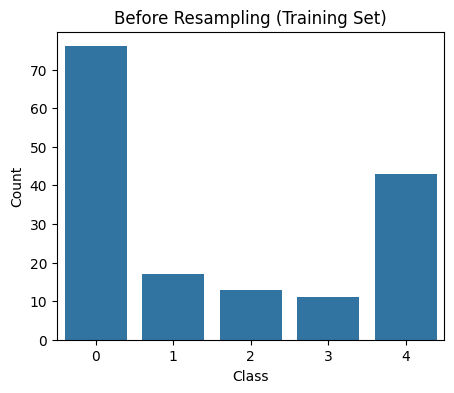

              precision    recall  f1-score   support

           0       0.88      0.93      0.90        15
           1       0.86      1.00      0.92         6
           2       1.00      1.00      1.00         3
           3       1.00      0.80      0.89         5
           4       1.00      0.91      0.95        11

    accuracy                           0.93        40
   macro avg       0.95      0.93      0.93        40
weighted avg       0.93      0.93      0.93        40



In [21]:
# Approach 1: Train model directly

plot_class_distribution(y_train, "Before Resampling (Training Set)")
 
model1 = LogisticRegression(max_iter=1000, random_state=42) 
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
print(classification_report(y_test, y_pred1))


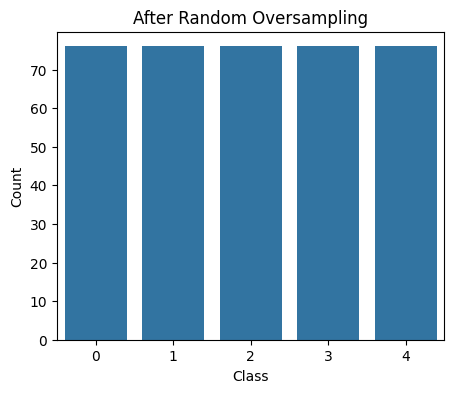

              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.86      1.00      0.92         6
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00        11

    accuracy                           0.97        40
   macro avg       0.97      0.99      0.98        40
weighted avg       0.98      0.97      0.98        40



In [22]:
# Approach 2: Random Oversampling
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)
plot_class_distribution(y_ros, "After Random Oversampling")
 
model2 = LogisticRegression(max_iter=1000, random_state=42) 
model2.fit(X_ros, y_ros)
y_pred2 = model2.predict(X_test)
print(classification_report(y_test, y_pred2))


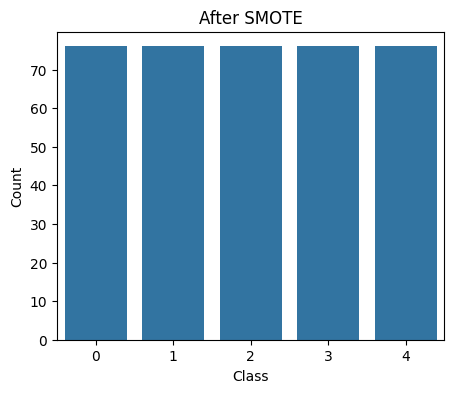

              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.86      1.00      0.92         6
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00        11

    accuracy                           0.97        40
   macro avg       0.97      0.99      0.98        40
weighted avg       0.98      0.97      0.98        40



In [23]:
# Approach 3: SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

plot_class_distribution(y_smote, "After SMOTE")
 
model3 = LogisticRegression(max_iter=1000, random_state=42) 
model3.fit(X_smote, y_smote)
y_pred3 = model3.predict(X_test)
print(classification_report(y_test, y_pred3))

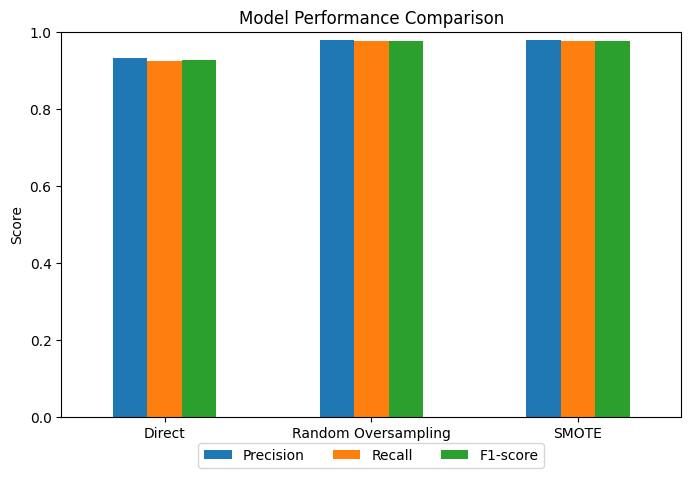

In [24]:
metrics = {
    "Direct": [
        precision_score(y_test, y_pred1, average='weighted'),
        recall_score(y_test, y_pred1, average='weighted'),
        f1_score(y_test, y_pred1, average='weighted'),
    ],
    "Random Oversampling": [
        precision_score(y_test, y_pred2, average='weighted'),
        recall_score(y_test, y_pred2, average='weighted'),
        f1_score(y_test, y_pred2, average='weighted'),
    ],
    "SMOTE": [
        precision_score(y_test, y_pred3, average='weighted'),
        recall_score(y_test, y_pred3, average='weighted'),
        f1_score(y_test, y_pred3, average='weighted'),
    ],
}

metrics_df = pd.DataFrame(metrics, index=["Precision", "Recall", "F1-score"])

metrics_df.T.plot(kind='bar', figsize=(8,5))
plt.title("Model Performance Comparison")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.show()